In [ ]:
!pip install -U datasets

In [ ]:
import numpy as np
import tensorflow as tf
from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from collections import Counter
from tensorflow.keras import  layers
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
ds = load_dataset("lumenggan/avatar-the-last-airbender-tagged", split="train[:100]")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
ds

Dataset({
    features: ['image', 'tags'],
    num_rows: 5000
})

In [ ]:
def preprocess_image(img_data):
    img = img_data['image']
    if img.mode != 'RGB':
        img = img.convert('RGB')
    img = img.resize((224, 224))
    arr = np.array(img, dtype=np.float16) / 255.0
    return arr

In [ ]:
images = np.stack([preprocess_image(x) for x in ds])
print(f"Обработано изображений: {len(images)}")

Начало предобработки изображений...
Обработано изображений: 100


In [ ]:
tags = [x['tags'] for x in ds]

all_tags = [tag for sublist in tags for tag in sublist]
tag_counts = Counter(all_tags)
top_tags = set(tag for tag, count in tag_counts.most_common(35))

filtered_tags = [
    [tag for tag in tag_list if tag in top_tags]
    for tag_list in tags
]

tokenizer = Tokenizer(oov_token="<OOV>", filters='')
tokenizer.fit_on_texts([['<start>', '<end>']])
tokenizer.fit_on_texts(filtered_tags)
vocab_size = len(tokenizer.word_index) + 1
tokenized_sequences = []
for tag_list in filtered_tags:
    sequence_with_special_tokens = ['<start>'] + tag_list + ['<end>']
    tokenized_sequences.append(sequence_with_special_tokens)

seqs = tokenizer.texts_to_sequences(tokenized_sequences)

max_len = max(len(s) for s in seqs)
y = pad_sequences(seqs, maxlen=max_len, padding='post')


In [ ]:
print(max([len(i) for i in filtered_tags]))

19


In [ ]:
len(tokenizer.word_index) + 1

39

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    images, y, test_size=0.2, random_state=42
)

In [ ]:
class JaccardTags(tf.keras.metrics.Metric):
    def __init__(self, name="jaccard_tags", **kwargs):
        super().__init__(name=name, **kwargs)
        self.total_jaccard = self.add_weight(name="total_jaccard", initializer="zeros")
        self.num_samples = self.add_weight(name="num_samples", initializer="zeros")

    def _create_sparse_set_from_1d_dense(self, dense_1d_tensor):
        """Converts a 1D dense tensor of unique elements into a SparseTensor representing a single set."""
        num_elements = tf.shape(dense_1d_tensor)[0]
        indices = tf.transpose(tf.stack([
            tf.zeros(num_elements, dtype=tf.int64),
            tf.range(num_elements, dtype=tf.int64)
        ]))
        values = dense_1d_tensor
        dense_shape = [1, tf.cast(num_elements, dtype=tf.int64)]

        return tf.SparseTensor(indices=indices, values=values, dense_shape=dense_shape)

    def _calculate_jaccard_for_sample(self, elements):
        true_seq, pred_seq = elements
        true_elements_no_pad_indices = tf.where(tf.not_equal(true_seq, 0))
        pred_elements_no_pad_indices = tf.where(tf.not_equal(pred_seq, 0))

        true_elements_no_pad = tf.gather_nd(true_seq, true_elements_no_pad_indices)
        pred_elements_no_pad = tf.gather_nd(pred_seq, pred_elements_no_pad_indices)
        s_true_unique = tf.unique(true_elements_no_pad)[0]
        s_pred_unique = tf.unique(pred_elements_no_pad)[0]
        sparse_true_set = self._create_sparse_set_from_1d_dense(s_true_unique)
        sparse_pred_set = self._create_sparse_set_from_1d_dense(s_pred_unique)
        intersect = tf.sets.intersection(sparse_true_set, sparse_pred_set)
        union = tf.sets.union(sparse_true_set, sparse_pred_set)
        union_size = tf.cast(tf.size(union.values), tf.float32)
        j_index = tf.cond(
            tf.equal(union_size, 0.0),
            lambda: tf.constant(1.0, dtype=tf.float32),
            lambda: tf.cast(tf.size(intersect.values), tf.float32) / (union_size + 1e-8)
        )
        return j_index

    def update_state(self, y_true, y_pred, sample_weight=None):
        pred_ids = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        y_true = tf.cast(y_true, dtype=tf.int32)

        jaccard_indices_batch = tf.map_fn(
            self._calculate_jaccard_for_sample,
            (y_true, pred_ids),
            fn_output_signature=tf.float32
        )

        if sample_weight is not None:
            sample_weight = tf.cast(sample_weight, dtype=tf.float32)
            weighted_jaccard_indices = jaccard_indices_batch * sample_weight
            self.total_jaccard.assign_add(tf.reduce_sum(weighted_jaccard_indices))
            self.num_samples.assign_add(tf.reduce_sum(sample_weight))
        else:
            self.total_jaccard.assign_add(tf.reduce_sum(jaccard_indices_batch))
            self.num_samples.assign_add(tf.cast(tf.shape(y_true)[0], dtype=tf.float32))

    def result(self):
        return tf.cond(tf.equal(self.num_samples, 0),
                       lambda: tf.constant(0.0),
                       lambda: self.total_jaccard / self.num_samples)

    def reset_state(self):
        self.total_jaccard.assign(0.0)
        self.num_samples.assign(0.0)

In [ ]:
class TagDecoder(tf.keras.layers.Layer):
    def __init__(self, model_type: str, hidden_units: int, num_layers: int, output_vocab_size: int, max_sequence_length: int, **kwargs):
        super().__init__(**kwargs)
        self.model_type = model_type.lower()
        self.hidden_units = hidden_units
        self.num_layers = num_layers
        self.output_vocab_size = output_vocab_size
        self.max_sequence_length = max_sequence_length
        self.cells = []

    def build(self, input_shape):
        for i in range(self.num_layers):
            if self.model_type == "gru":
                cell = tf.keras.layers.GRU(self.hidden_units,
                                           return_sequences=True,
                                           dropout=0.2,
                                           recurrent_dropout=0.2)
            else:
                cell = tf.keras.layers.LSTM(self.hidden_units,
                                            return_sequences=True,
                                            dropout=0.2,
                                            recurrent_dropout=0.2)
            self.cells.append(cell)

        self.out_layer = tf.keras.layers.TimeDistributed(
            tf.keras.layers.Dense(self.output_vocab_size, activation='softmax')
        )
        super().build(input_shape)

    def call(self, feat_vec):
        x = tf.repeat(tf.expand_dims(feat_vec, 1), repeats=self.max_sequence_length, axis=1)
        for cell in self.cells:
            x = cell(x)

        return self.out_layer(x)

    def get_config(self):
        config = super().get_config()
        config.update({
            "model_type": self.model_type,
            "hidden_units": self.hidden_units,
            "num_layers": self.num_layers,
            "output_vocab_size": self.output_vocab_size,
            "max_sequence_length": self.max_sequence_length
        })
        return config


In [ ]:
def plot_training_history(history):
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    train_accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    train_jaccarda = history.history['jaccard_tags']
    val_jaccarda = history.history['val_jaccard_tags']
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(train_jaccarda, label='Training jaccard_tags')
    plt.plot(val_jaccarda, label='Validation jaccard_tags')
    plt.title('Training and Validation jaccard_tags')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(train_accuracy, label='Training Accuracy')
    plt.plot(val_accuracy, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
base_encoder = tf.keras.applications.EfficientNetB0(
    include_top=False, pooling='avg', weights='imagenet'
)
base_encoder.trainable = False

img_input = tf.keras.Input(shape=(224, 224, 3), name="image_input")
features = base_encoder(img_input, training=False)
projected_features = tf.keras.layers.Dense(256, activation='relu', name="projection_layer")(features)

tag_decoder = TagDecoder(
    model_type="gru",
    hidden_units=256,
    num_layers=4,
    output_vocab_size=vocab_size,
    max_sequence_length=max_len,
    name="tag_decoder"
)
output_tags = tag_decoder(projected_features)

model = tf.keras.Model(inputs=img_input, outputs=output_tags, name="ImageTagger")
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', JaccardTags()]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ImageTagger"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_layer (Dense)        │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tag_decoder (TagDecoder)        │ (None, 21, 39)         │     1,589,031 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,966,538 (22.76 MB)

 Trainable params: 1,916,967 (7.31 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
epochs = 10
batch_size = 32

history = model.fit(X_train, y_train,validation_data=(X_val, y_val),epochs=epochs,
                    batch_size=batch_size, callbacks=[
                    tf.keras.callbacks.EarlyStopping(monitor='val_jaccard_tags', mode='max', patience=5, restore_best_weights=True),
                    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_jaccard_tags', mode='max', factor=0.2, patience=2, min_lr=1e-6)
]
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 68s 362ms/step - accuracy: 0.6027 - jaccard_tags: 0.1008 - loss: 1.7293 - val_accuracy: 0.6808 - val_jaccard_tags: 0.2526 - val_loss: 1.2286 - learning_rate: 0.0010
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 71s 305ms/step - accuracy: 0.6788 - jaccard_tags: 0.2651 - loss: 1.2247 - val_accuracy: 0.6768 - val_jaccard_tags: 0.3611 - val_loss: 1.2341 - learning_rate: 0.0010
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 308ms/step - accuracy: 0.6803 - jaccard_tags: 0.2622 - loss: 1.2149 - val_accuracy: 0.6784 - val_jaccard_tags: 0.2248 - val_loss: 1.2237 - learning_rate: 0.0010
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 301ms/step - accuracy: 0.6834 - jaccard_tags: 0.2480 - loss: 1.2065 - val_accuracy: 0.6754 - val_jaccard_tags: 0.2361 - val_loss: 1.2240 - learning_rate: 0.0010
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 302ms/step - accuracy: 0.6793 - jaccard_tags: 0.2420 - loss: 1.2025 - val_accuracy: 0.6808 - val_jaccard_tags: 0.2526 - val_loss: 1.2127

In [ ]:
def generate_image_tags(model, image_data, tokenizer, max_sequence_length):
    input_image_tensor = tf.convert_to_tensor(image_data, dtype=tf.float32)
    input_image_tensor = tf.expand_dims(input_image_tensor, axis=0)
    predictions = model.predict(input_image_tensor)
    predicted_tag_indices = np.argmax(predictions[0], axis=-1)
    decoded_tags = []
    for idx in predicted_tag_indices:
        word = tokenizer.index_word.get(idx, tokenizer.oov_token)
        if word == '<end>':
            break
        if word not in ['<pad>', '<start>', tokenizer.oov_token]:
            decoded_tags.append(word)

    return decoded_tags

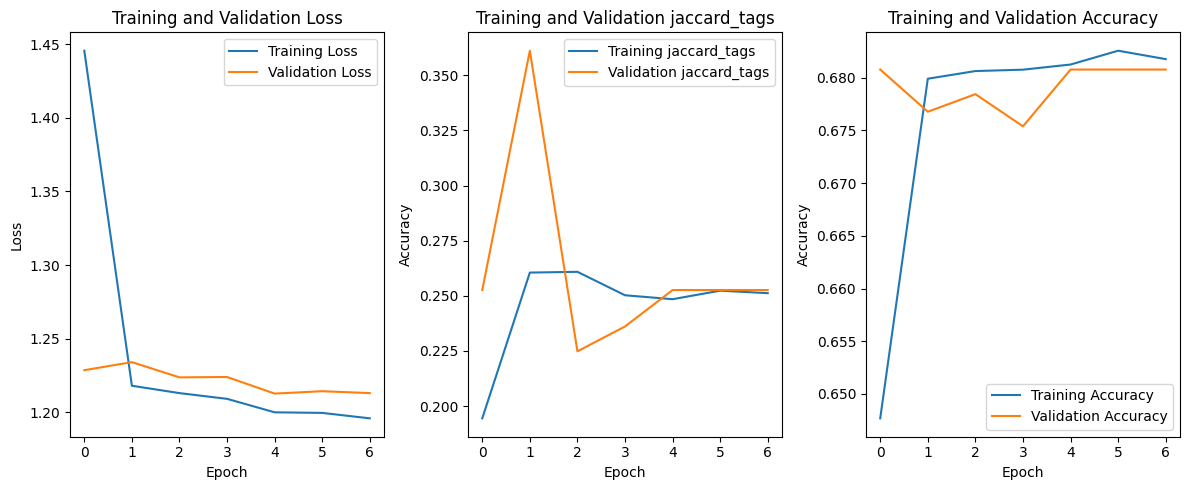

In [ ]:
plot_training_history(history)

In [ ]:
base_encoder = tf.keras.applications.EfficientNetB0(
    include_top=False, pooling='avg', weights='imagenet'
)
base_encoder.trainable = False

img_input = tf.keras.Input(shape=(224, 224, 3), name="image_input")
features = base_encoder(img_input, training=False)
projected_features = tf.keras.layers.Dense(256, activation='relu', name="projection_layer")(features)

tag_decoder = TagDecoder(
    model_type="lstm",
    hidden_units=256,
    num_layers=3,
    output_vocab_size=vocab_size,
    max_sequence_length=max_len,
    name="tag_decoder"
)
output_tags = tag_decoder(projected_features)


model_lstm = tf.keras.Model(inputs=img_input,
                            outputs=output_tags,
                            name="ImageTagger")


model_lstm.compile(
    optimizer=tf.keras.optimizers.AdamW(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', JaccardTags()]
)

model_lstm.summary()

Model: "ImageTagger"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_layer (Dense)        │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tag_decoder (TagDecoder)        │ (None, 21, 39)         │     1,585,959 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,963,466 (22.75 MB)

 Trainable params: 1,913,895 (7.30 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
epochs = 10
batch_size = 32

history_lstm = model_lstm.fit(X_train, y_train,validation_data=(X_val, y_val),epochs=epochs,
                    batch_size=batch_size, callbacks=[
                    tf.keras.callbacks.EarlyStopping(monitor='val_jaccard_tags', mode='max', patience=5, restore_best_weights=True),
                    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_jaccard_tags', mode='max', factor=0.2, patience=2, min_lr=1e-6)
]
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 59s 325ms/step - accuracy: 0.5944 - jaccard_tags: 0.1016 - loss: 1.7368 - val_accuracy: 0.6790 - val_jaccard_tags: 0.2526 - val_loss: 1.2669 - learning_rate: 0.0010
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 35s 277ms/step - accuracy: 0.6802 - jaccard_tags: 0.2530 - loss: 1.2383 - val_accuracy: 0.6791 - val_jaccard_tags: 0.2659 - val_loss: 1.2203 - learning_rate: 0.0010
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 276ms/step - accuracy: 0.6801 - jaccard_tags: 0.2473 - loss: 1.2020 - val_accuracy: 0.6808 - val_jaccard_tags: 0.2526 - val_loss: 1.2193 - learning_rate: 0.0010
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 278ms/step - accuracy: 0.6829 - jaccard_tags: 0.2486 - loss: 1.1989 - val_accuracy: 0.6808 - val_jaccard_tags: 0.2526 - val_loss: 1.2166 - learning_rate: 0.0010
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 277ms/step - accuracy: 0.6809 - jaccard_tags: 0.2553 - loss: 1.2068 - val_accuracy: 0.6808 - val_jaccard_tags: 0.2526 - val_loss: 1.2133

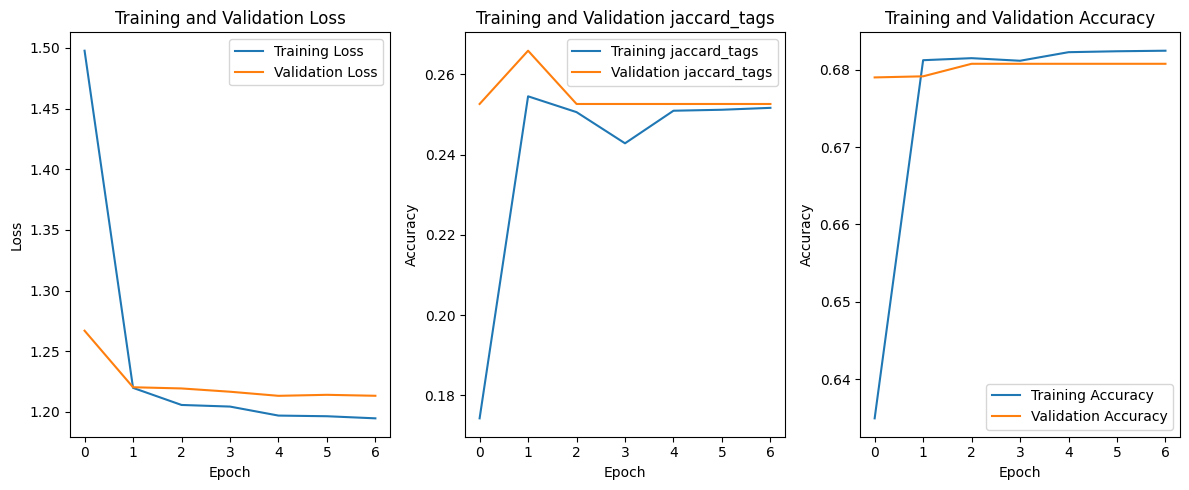

In [ ]:
plot_training_history(history_lstm)